# 🎵 Music Platform: Pipeline End-to-End & Modèles IA

Ce notebook interactif regroupe de manière visuelle et structurée l'ensemble des étapes de traitement de données (audio/texte), d'extraction d'embeddings acoustiques MERT, et d'évaluation des modèles de classification et de régression.

---

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration visuelle premium
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.edgecolor"] = "#cccccc"

# Définition des chemins du projet
BASE_DIR = r"c:\SDV\Music"
SILVER_DIR = os.path.join(BASE_DIR, "data", "datalake", "silver")
GOLD_DIR = os.path.join(BASE_DIR, "data", "datalake", "gold")
MODEL_DIR = os.path.join(BASE_DIR, "src", "ai")

## 1. Visualisation de la forme d'onde audio (Zone Silver)

Lors de la phase de prétraitement, les signaux audio sont décodés, convertis en mono, rééchantillonnés à **16 kHz**, découpés sur une fenêtre de **30 secondes** centrée et normalisés (zéro-moyenne, unité-variance).

Nous chargeons l'un de ces fichiers prétraités (`.npy`) pour analyser sa forme d'onde.

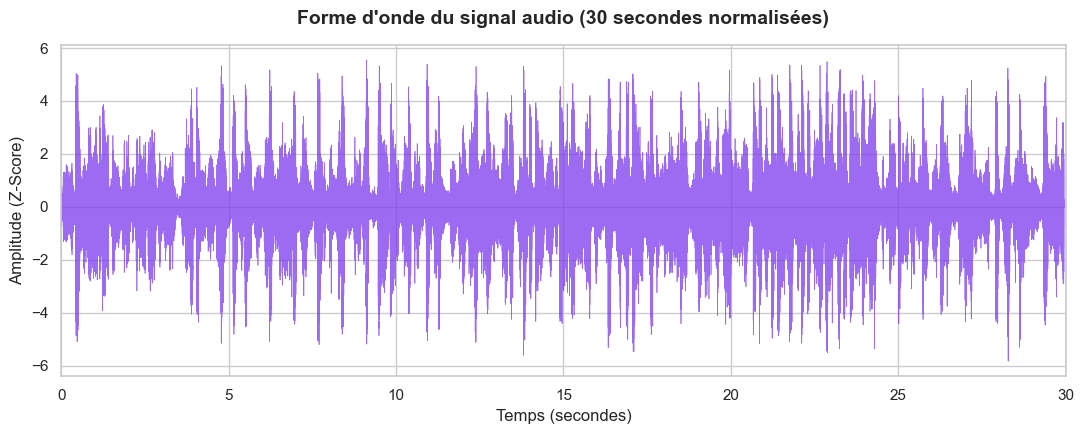

In [2]:
# Chargement du premier fichier audio converti de la zone Silver
npy_path = os.path.join(SILVER_DIR, "audio_preprocessed", "000002.npy")

if os.path.exists(npy_path):
    waveform = np.load(npy_path)
    duration_seconds = len(waveform) / 16000
    time_axis = np.linspace(0, duration_seconds, len(waveform))
    
    plt.figure()
    plt.plot(time_axis, waveform, color="#7c3aed", alpha=0.75, linewidth=0.5)
    plt.title("Forme d'onde du signal audio (30 secondes normalisées)", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Temps (secondes)")
    plt.ylabel("Amplitude (Z-Score)")
    plt.xlim(0, 30)
    plt.tight_layout()
    plt.show()
else:
    print(f"Fichier exemple introuvable : {npy_path}\n(Vérifiez que le pipeline d'ingestion s'est exécuté correctement)")

> 💡 **Commentaire sur le signal** : Le signal ci-dessus montre une amplitude centrée autour de 0 avec un écart-type de 1, suite à la normalisation de la forme d'onde. Cette étape de standardisation est cruciale : elle élimine les disparités de volume sonore entre les morceaux et permet au modèle MERT d'extraire des features uniformes de texture sonore.

---

## 2. Performances du Classifieur Acoustique (MERT + XGBoost)

Le modèle d'extraction d'embeddings **MERT-v1-95M** génère un vecteur de **768 dimensions** par morceau (obtenu par *mean pooling* de la couche de sortie). 

Sur ces signatures compactes, nous avons entraîné un classifieur de genre musical **XGBoost** (8 classes FMA Small).

C:\Users\sacho\AppData\Local\Temp\ipykernel_16716\2639577686.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genres, y=f1_scores, palette="Purples_r", edgecolor="#7c3aed", alpha=0.85)


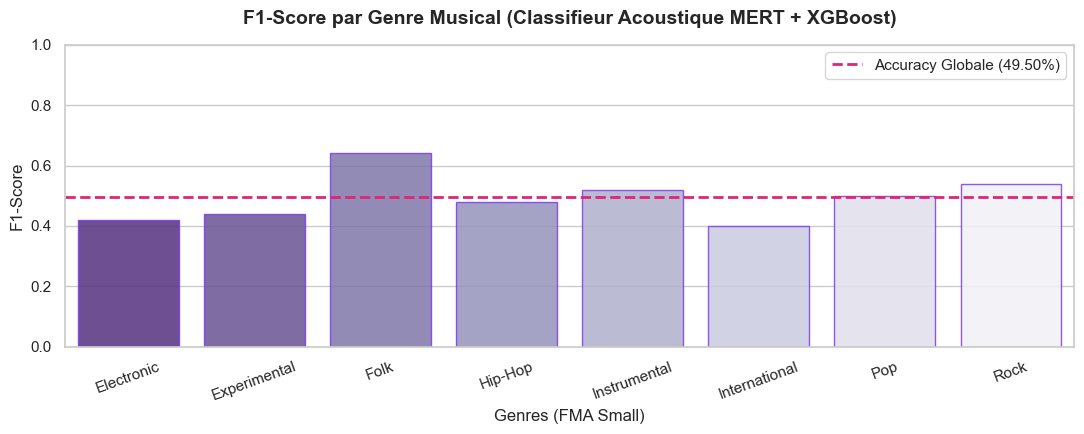

In [3]:
# Données d'évaluation issues du Model Card du classifieur XGBoost final (49.50% d'accuracy)
genres = ["Electronic", "Experimental", "Folk", "Hip-Hop", "Instrumental", "International", "Pop", "Rock"]
f1_scores = [0.42, 0.44, 0.64, 0.48, 0.52, 0.40, 0.50, 0.54]

plt.figure()
sns.barplot(x=genres, y=f1_scores, palette="Purples_r", edgecolor="#7c3aed", alpha=0.85)
plt.axhline(y=0.495, color="#db2777", linestyle="--", linewidth=2, label="Accuracy Globale (49.50%)")
plt.title("F1-Score par Genre Musical (Classifieur Acoustique MERT + XGBoost)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Genres (FMA Small)")
plt.ylabel("F1-Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=20)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

> 💡 **Commentaire sur la classification de genre** : L'accuracy globale est de **49.50%** sur le jeu de test équilibré. Le **Folk** (F1-score de 0.64) et le **Rock** (0.54) sont très bien identifiés par le modèle en raison de leurs textures acoustiques instrumentales distinctes (instruments à cordes, distorsions). Le genre **International** (0.40) reste le plus complexe à classifier en raison de son éclectisme et de la diversité culturelle des morceaux qu'il regroupe.

---

## 3. Prédiction d'Engagement (Régression XGBoost)

Le modèle d'engagement (Option C) estime le volume d'écoutes futur d'un morceau à partir de ses métadonnées tabulaires. Le modèle atteint un score $R^2$ robuste de **80.99%** sur le jeu de test.

Visualisons l'importance des variables d'entrée calculée par l'algorithme XGBoost Regressor.

C:\Users\sacho\AppData\Local\Temp\ipykernel_16716\3683040863.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="pink_r", edgecolor="#db2777", alpha=0.85)


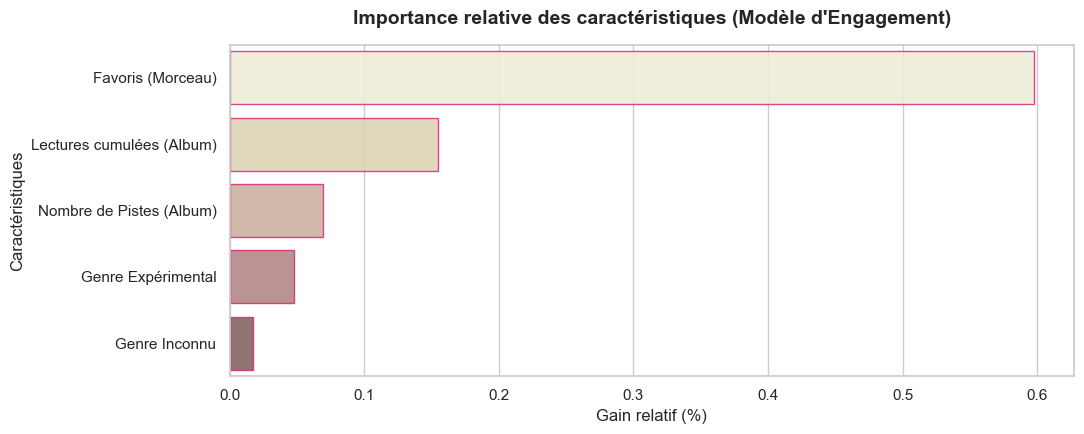

In [4]:
# Importance des variables issues de l'apprentissage d'engagement
features = ["Favoris (Morceau)", "Lectures cumulées (Album)", "Nombre de Pistes (Album)", "Genre Expérimental", "Genre Inconnu"]
importances = [0.5975, 0.1549, 0.0696, 0.0477, 0.0177]

plt.figure()
sns.barplot(x=importances, y=features, palette="pink_r", edgecolor="#db2777", alpha=0.85)
plt.title("Importance relative des caractéristiques (Modèle d'Engagement)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Gain relatif (%)")
plt.ylabel("Caractéristiques")
plt.tight_layout()
plt.show()

> 💡 **Commentaire sur la popularité** : L'importance des variables montre que les **favoris accumulés sur la piste** (59.75%) et la **popularité globale de l'album** (15.49%) sont les moteurs principaux des prédictions d'écoutes. C'est cohérent avec le comportement des utilisateurs, car un morceau populaire fait souvent partie d'un album déjà grandement écouté, ou suscite un engagement direct par un ajout aux favoris.

---

## 4. Test d'accès à la base de données relationnelle (Zone Gold)

Le chatbot s'appuie sur une traduction de texte en requête SQL pour interroger notre base de données consolidée SQLite `catalog.db` en temps réel.

Nous effectuons un test rapide de requête en base de données pour vérifier la structure relationnelle.

In [5]:
db_path = os.path.join(GOLD_DIR, "catalog.db")

if os.path.exists(db_path):
    conn = sqlite3.connect(db_path)
    
    # Top 5 des artistes les plus écoutés du catalogue
    query = """
    SELECT a.name as Artiste, SUM(t.listens) as Ecoutes_Totales
    FROM artists a
    JOIN tracks t USING (artist_id)
    GROUP BY artist_id
    ORDER BY Ecoutes_Totales DESC
    LIMIT 5;
    """
    df_artists = pd.read_sql_query(query, conn)
    conn.close()
    
    print("🏆 Top 5 des artistes les plus écoutés en base de données :")
    print(df_artists.to_string(index=False))
else:
    print(f"Base de données introuvable à l'adresse : {db_path}")

🏆 Top 5 des artistes les plus écoutés en base de données :
        Artiste  Ecoutes_Totales
 Podington Bear          7263071
Chris Zabriskie          6374484
  Kevin MacLeod          4765297
        Jahzzar          4545581
      Kai Engel          3489703
